# Predicción de subscripción a un producto bancario

## 1. EDA

Para hacer un EDA, debemos usar pickle para deserializar los datos.

### 1.1. Instalación de pickle y pandas

In [2]:
%pip install pandas 

Note: you may need to restart the kernel to use updated packages.


### 1.2. Deserialización de los datos

Con la librería pickle, extraemos los datos de forma sencilla. 

In [3]:
import pickle as pkl
import pandas as pd
import numpy as np
import os

#Hay que aññadir la semilla
SEED = 64

file = "./dataset/bank_10.pkl"

if os.path.exists(file):
    with open(file, 'rb') as fd:
        df = pkl.load(fd)
        print(df)


       age          job  marital  education default  balance housing loan  \
0       59       admin.  married  secondary      no     2343     yes   no   
1       56         None  married  secondary      no       45      no   no   
2       41   technician  married  secondary      no     1270     yes   no   
3       55         None  married  secondary      no     2476     yes   no   
4       54       admin.     None   tertiary      no      184      no   no   
...    ...          ...      ...        ...     ...      ...     ...  ...   
11157   33  blue-collar   single    primary      no        1     yes   no   
11158   39     services  married  secondary      no      733      no   no   
11159   32   technician   single  secondary      no       29      no   no   
11160   43   technician  married  secondary      no        0      no  yes   
11161   34   technician  married  secondary      no        0      no   no   

        contact  day month  duration  campaign  pdays  previous poutcome  \

C:\Users\Sergio\AppData\Local\Temp\ipykernel_27604\3042229159.py:13: DeprecationWarning: numpy.core.numeric is deprecated and has been renamed to numpy._core.numeric. The numpy._core namespace contains private NumPy internals and its use is discouraged, as NumPy internals can change without warning in any release. In practice, most real-world usage of numpy.core is to access functionality in the public NumPy API. If that is the case, use the public NumPy API. If not, you are using NumPy internals. If you would still like to access an internal attribute, use numpy._core.numeric._frombuffer.
  df = pkl.load(fd)


### 1.3. Análisis de variables e instancias

A continuación, analizaremos tanto el número de variables y de instancias, así como sus principales características. 

En cuanto al número de variables y de instancias se puede observar fácilmente de la siguiente forma. 

In [4]:
n_vars = len(df.columns) # Número de variables
n_instances = len(df) # Número de instancias

print(f"Número de variables: {n_vars}\nNúmero de instancias: {n_instances}")


Número de variables: 17
Número de instancias: 11000


Antes de continuar, para evitar futuros problemas, reemplazaremos posibles textos que puedan ser malinterpretados como NaN. 

In [5]:
# Reemplazar valores que representan faltantes
df = df.replace(['None', 'null', 'NaN', 'N/A', ''], np.nan)

Debemos identificar si es un problema de clasificación o regresión, y en caso de ser clasificación, analizar el desbalanceo.

In [6]:
target_col = 'deposit'

print("Tipo de problema:")
if df[target_col].dtype == 'object' or df[target_col].nunique() < 10:
    print("Clasificación binaria")
else:
    print("Regresión")

print("\nDistribución de la variable objetivo:")
print(df[target_col].value_counts())

print("\nPorcentaje:")
print(df[target_col].value_counts(normalize=True) * 100)

Tipo de problema:
Clasificación binaria

Distribución de la variable objetivo:
deposit
no     5780
yes    5220
Name: count, dtype: int64

Porcentaje:
deposit
no     52.545455
yes    47.454545
Name: proportion, dtype: float64


Sabiendo que el número de variables es 17, nos gustaría saber cuántas de ellas son numéricas, cuántas son categóricas y cuántas son ordinales. 

In [7]:
num_vars = df.select_dtypes(include=['number']).columns.tolist() # Variables numéricas

card_ord_vars = df.select_dtypes(include=['object', 'category']) # Variables categóricas y ordinales

# Ahora debemos distinguir cuáles son categóricas y cuáles son ordinales
for var in card_ord_vars.columns:
    print(f"Variable {var} tiene los valores {df[var].unique()}")

Variable job tiene los valores ['admin.' None 'technician' 'management' 'retired' 'services'
 'blue-collar' 'unemployed' 'entrepreneur' 'housemaid' 'unknown'
 'self-employed' 'student']
Variable marital tiene los valores ['married' None 'single' 'divorced']
Variable education tiene los valores ['secondary' 'tertiary' 'primary' 'unknown']
Variable default tiene los valores ['no' 'yes']
Variable housing tiene los valores ['yes' 'no']
Variable loan tiene los valores ['no' 'yes']
Variable contact tiene los valores ['unknown' 'cellular' 'telephone']
Variable month tiene los valores ['may' 'jun' 'jul' 'aug' 'oct' 'nov' 'dec' 'jan' 'feb' 'mar' 'apr' 'sep']
Variable poutcome tiene los valores ['unknown' 'other' 'failure' 'success']
Variable deposit tiene los valores ['yes' 'no']


Viendo los valores, podemos entonces ver que hay algunas de ellas que mantienen un orden, y por tanto, son ordinales. 

Estas variables son:

Education

Month

Por tanto, el resto serán categóricas

In [8]:
ord_vars = [] # Añadimos las variables ordinales a la lista
for var in card_ord_vars.columns:
    if var == 'education':  # primary < secondary < tertiary
        ord_vars.append(var)
    elif var == 'month':  # orden temporal
        ord_vars.append(var)

# El resto son categóricas
cat_vars = [var for var in card_ord_vars.columns if var not in ord_vars]

print(f"Variables numéricas: {", ".join(num_vars) if num_vars else "No se encontraron variables numéricas"}")
print(f"Variables categóricas: {", ".join(cat_vars) if cat_vars else "No se encontraron variables categóricas"}")
print(f"Variables ordinales: {", ".join(ord_vars) if ord_vars else "No se encontraron variables ordinales"}")

Variables numéricas: age, balance, day, duration, campaign, pdays, previous
Variables categóricas: job, marital, default, housing, loan, contact, poutcome, deposit
Variables ordinales: education, month


Ahora que ya hemos distinguido entre variables categóricas y ordinales, debemos analizar su cardinalidad

In [9]:
cat_hcard_var = [] # Variables categóricas con alta cardinalidad
ord_hcard_var = [] # Variables ordinales con alta cardinalidad

# Vamos a definir una variable de alta cardinalidad cuando hay más de 10 valores únicos
for var in cat_vars:
    if df[var].nunique() > 10:
        cat_hcard_var.append(var)

for var in ord_vars:
    if df[var].nunique() > 10:
        cat_hcard_var.append(var)

print(f"Variables categóricas con alta cardinalidad: {", ".join(cat_hcard_var) if cat_hcard_var else "No se encontraron elementos"}")
print(f"Variables ordinales con alta cardinalidad: {", ".join(ord_hcard_var) if ord_hcard_var else "No se encontraron elementos"}")

Variables categóricas con alta cardinalidad: job, month
Variables ordinales con alta cardinalidad: No se encontraron elementos


Por tanto, a modo de resumen, tenemos

In [10]:
print(f"Variables númericas: {", ".join(num_vars) if num_vars else "No se encontraron elementos"}")
print("_________________________________________________________________________________________")
print(f"Variables categóricas: {", ".join(cat_vars) if cat_vars else "No se encontraron elementos"}")
print(f"\tDe las cuales con alta cardinalidad: {", ".join(cat_hcard_var) if cat_hcard_var else "No se encontraron elementos"}")
print("_________________________________________________________________________________________")
print(f"Variables númericas: {", ".join(ord_vars) if ord_vars else "No se encontraron elementos"}")
print(f"\tDe las cuales con alta cardinalidad: {", ".join(ord_hcard_var) if ord_hcard_var else "No se encontraron elementos"}")

Variables númericas: age, balance, day, duration, campaign, pdays, previous
_________________________________________________________________________________________
Variables categóricas: job, marital, default, housing, loan, contact, poutcome, deposit
	De las cuales con alta cardinalidad: job, month
_________________________________________________________________________________________
Variables númericas: education, month
	De las cuales con alta cardinalidad: No se encontraron elementos


Ahora que tenemos una idea más clara de cómo son las variables, debemos analizar cuales de ellas tienen valores faltantes y, en ese caso, cuánta cantidad de ellos

In [11]:
# Creamos una lista de tuplas donde cada elemento es una tupla de dos elementos
# Primer elemento: variable
# Segundo elemento: número de valores faltantes
missing_values_count = []

for col in df.columns:
    n_null = df[col].isnull().sum() # Contamos el número de valores faltantes
    missing_values_count.append((col, int(n_null)))

    if n_null > 0:
        print(f"La variable {col} tiene {n_null} valores faltantes")
    else:
        print(f"La variable {col} no tiene valores faltantes")

La variable age no tiene valores faltantes
La variable job tiene 332 valores faltantes
La variable marital tiene 183 valores faltantes
La variable education no tiene valores faltantes
La variable default no tiene valores faltantes
La variable balance no tiene valores faltantes
La variable housing no tiene valores faltantes
La variable loan no tiene valores faltantes
La variable contact no tiene valores faltantes
La variable day no tiene valores faltantes
La variable month no tiene valores faltantes
La variable duration no tiene valores faltantes
La variable campaign no tiene valores faltantes
La variable pdays no tiene valores faltantes
La variable previous no tiene valores faltantes
La variable poutcome no tiene valores faltantes
La variable deposit no tiene valores faltantes


### 1.X. Visualización de los datos

Para poder visualizar mejor los datos y hacer un análisis de ellos, usaremos streamlit.

In [12]:
#!pip install streamlit

De esta forma, podremos ver de forma más visual algunas propiedades de los datos.

In [13]:
%%writefile visualizer.py
import pandas as pd
import streamlit as st

import pickle as pkl

file = "./dataset/bank_10.pkl"

with open(file, 'rb') as fd:
    df = pkl.load(fd)
    print(df)

# Extract the number of variables and instances
df_shape = df.shape

# Create a chart
st.subheader("Número de instancias y variables")
st.table(df_shape, columns=["Instancias", "Variables"])


Overwriting visualizer.py


### 1.4 Correr la aplicación

Para visualizar los datos, ejecutamos el siguiente comando:

In [14]:
#!streamlit run visualizer.py

### 1.4. Detección de columnas constantes o IDs

Debemos verificar si hay columnas que tengan un solo valor único (constantes) o que sean posibles identificadores.

In [15]:
# Columnas constantes (un solo valor único)
constant_cols = [col for col in df.columns if df[col].nunique() <= 1]

print("Columnas constantes (1 valor único):")
if constant_cols:
    for col in constant_cols:
        print(f"  - {col}: {df[col].unique()[0]}")
else:
    print("  No hay columnas constantes.")

# Posibles IDs (valores únicos = número de filas)
potential_ids = [col for col in df.columns if df[col].nunique() == len(df)]

print("\nPosibles columnas de ID (todos los valores únicos):")
if potential_ids:
    print(potential_ids)
else:
    print("  No hay columnas que parezcan IDs.")

Columnas constantes (1 valor único):
  No hay columnas constantes.

Posibles columnas de ID (todos los valores únicos):
  No hay columnas que parezcan IDs.


### 1.5. Análisis especial de la variable `pdays`

Según la descripción del dataset:
- `pdays`: Número de días desde que el cliente fue contactado en la campaña anterior
- **Valor -1 significa: sin contacto o desconocido**

Esta variable requiere un análisis y preprocesamiento especial.

In [16]:
print("="*60)
print("ANÁLISIS DE LA VARIABLE 'pdays'")
print("="*60)

if 'pdays' in df.columns:
    print("\nEstadísticas descriptivas de 'pdays':")
    print(df['pdays'].describe())
    
    # Contar valores -1
    n_minus_one = (df['pdays'] == -1).sum()
    pct_minus_one = (n_minus_one / len(df) * 100)
    
    print(f"\nValores = -1 (sin contacto previo): {n_minus_one} ({pct_minus_one:.2f}%)")
    print(f"Valores > 0 (con contacto previo): {(df['pdays'] > 0).sum()}")
    
    # Distribución de valores
    print(f"\nDistribución de valores:")
    print(f"  Mínimo: {df['pdays'].min()}")
    print(f"  Máximo: {df['pdays'].max()}")
    
    if (df['pdays'] > 0).sum() > 0:
        print(f"  Media (sin -1): {df[df['pdays'] > 0]['pdays'].mean():.2f}")
        print(f"  Mediana (sin -1): {df[df['pdays'] > 0]['pdays'].median():.2f}")

ANÁLISIS DE LA VARIABLE 'pdays'

Estadísticas descriptivas de 'pdays':
count    11000.000000
mean        51.308636
std        108.782842
min         -1.000000
25%         -1.000000
50%         -1.000000
75%         20.250000
max        854.000000
Name: pdays, dtype: float64

Valores = -1 (sin contacto previo): 8203 (74.57%)
Valores > 0 (con contacto previo): 2797

Distribución de valores:
  Mínimo: -1
  Máximo: 854
  Media (sin -1): 204.72
  Mediana (sin -1): 182.00


#### Estrategia de preprocesamiento para `pdays`

Dado que -1 representa "sin contacto previo" y aparece en un porcentaje significativo de los datos, la mejor estrategia es:

1. **Crear una variable binaria** `fue_contactado` que indique si el cliente fue contactado previamente (1) o no (0)
2. **Reemplazar los valores -1** en `pdays` por 0 para mantener la variable numérica válida

Esta estrategia permite que los modelos capturen tanto:
- **El hecho de haber sido contactado** (información categórica)
- **Cuánto tiempo hace del contacto** (información numérica)


In [17]:
# Implementar preprocesamiento de pdays
print("Aplicando preprocesamiento a 'pdays'...\n")

# Crear variable binaria
df['fue_contactado'] = (df['pdays'] > 0).astype(int)

# Reemplazar -1 con 0
df['pdays'] = df['pdays'].replace(-1, 0)

print("✓ Variable 'fue_contactado' creada:")
print(df['fue_contactado'].value_counts())

print("\n✓ Variable 'pdays' preprocesada (valores -1 → 0):")
print(f"  Valores únicos: {df['pdays'].nunique()}")
print(f"  Rango: [{df['pdays'].min()}, {df['pdays'].max()}]")

print("\nPreprocesamiento de 'pdays' completado.")

Aplicando preprocesamiento a 'pdays'...

✓ Variable 'fue_contactado' creada:
fue_contactado
0    8203
1    2797
Name: count, dtype: int64

✓ Variable 'pdays' preprocesada (valores -1 → 0):
  Valores únicos: 472
  Rango: [0, 854]

Preprocesamiento de 'pdays' completado.


### 1.6. Resumen del EDA

A continuación se presenta una tabla resumen con todos los hallazgos del análisis exploratorio:

In [18]:
# Calcular métricas para el resumen
n_categoricas = len(cat_vars)
n_numericas = len(num_vars)
n_ordinales = len(ord_vars)
n_alta_card = len(cat_hcard_var) + len(ord_hcard_var)
n_faltantes = len([x for x in missing_values_count if x[1] > 0])

print("="*60)
print("RESUMEN DEL EDA")
print("="*60)
print(f"\nDimensiones del dataset:")
print(f"  - Instancias: {n_instances}")
print(f"  - Variables (original): {n_vars}")
print(f"  - Variables (tras preprocesar pdays): {len(df.columns)}")

print(f"\nTipos de variables:")
print(f"  - Variables numéricas: {n_numericas}")
print(f"  - Variables categóricas: {n_categoricas}")
print(f"  - Variables ordinales: {n_ordinales}")

print(f"\nCaracterísticas especiales:")
print(f"  - Variables con alta cardinalidad (>10): {n_alta_card}")
if cat_hcard_var or ord_hcard_var:
    print(f"    Específicamente: {', '.join(cat_hcard_var + ord_hcard_var)}")
print(f"  - Variables con valores faltantes: {n_faltantes}")
if n_faltantes > 0:
    vars_faltantes = [x[0] for x in missing_values_count if x[1] > 0]
    print(f"    Específicamente: {', '.join(vars_faltantes)}")
print(f"  - Columnas constantes: {len(constant_cols)}")
print(f"  - Columnas de ID: {len(potential_ids)}")

print(f"\nProblema de ML:")
print(f"  - Tipo: Clasificación binaria")
print(f"  - Variable objetivo: deposit")
print(f"  - Distribución de clases: {df['deposit'].value_counts().to_dict()}")

# Calcular si está desbalanceado
class_pct = df['deposit'].value_counts(normalize=True) * 100
minority_pct = class_pct.min()
if minority_pct < 40:
    print(f"  - Desbalanceo: SÍ (clase minoritaria: {minority_pct:.2f}%)")
else:
    print(f"  - Desbalanceo: NO (clase minoritaria: {minority_pct:.2f}%)")

RESUMEN DEL EDA

Dimensiones del dataset:
  - Instancias: 11000
  - Variables (original): 17
  - Variables (tras preprocesar pdays): 18

Tipos de variables:
  - Variables numéricas: 7
  - Variables categóricas: 8
  - Variables ordinales: 2

Características especiales:
  - Variables con alta cardinalidad (>10): 2
    Específicamente: job, month
  - Variables con valores faltantes: 2
    Específicamente: job, marital
  - Columnas constantes: 0
  - Columnas de ID: 0

Problema de ML:
  - Tipo: Clasificación binaria
  - Variable objetivo: deposit
  - Distribución de clases: {'no': 5780, 'yes': 5220}
  - Desbalanceo: NO (clase minoritaria: 47.45%)


## 2. DECIDIR CÓMO SE VA A REALIZAR LA EVALUACIÓN

Para hacer un EDA, debemos usar pickle para deserializar los datos.

### 2.1. Estimación del rendimiento futuro

La estimación del rendimiento futuro se realizará con Holdout, dividiendo el conunto del dataset en (2/3) para el entrenamiento y el (1/3) restante para tests

In [19]:
# Definimos nuestra mñetrica de evaluación
print("\nMétrica de evaluación elegida:")

METRICA = "accuracy"
print(f"  - {METRICA}")
print("Justificación:")
print("\t La métrica 'accuracy' es adecuada para este problema de clasificación binaria")
print("\t Ya que no hay un desbalanceo severo entre las clases, 'accuracy' nos dará una buena medida del rendimiento general del modelo.")



Métrica de evaluación elegida:
  - accuracy
Justificación:
	 La métrica 'accuracy' es adecuada para este problema de clasificación binaria
	 Ya que no hay un desbalanceo severo entre las clases, 'accuracy' nos dará una buena medida del rendimiento general del modelo.


### 2.3 Separación de datos

Separamos las características y las variables objetivos en X e Y, y despues creamos los conjuntos train y test de cada una


In [20]:
%pip install scikit-learn

Note: you may need to restart the kernel to use updated packages.


In [21]:
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

# Separar características (X) y variable objetivo (y)
x = df.drop(columns=['deposit'])
y = df['deposit']

# Dividir los datos en conjuntos de entrenamiento y prueba
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=1/3, random_state=SEED)

print("="*50)
print("RESUMEN DE LOS CONJUNTOS DE DATOS")
print("="*50)

# Tamaño de los conjuntos
print("\nTamaño de los datasets:")
print(f"X_train: {x_train.shape}")
print(f"X_test:  {x_test.shape}")
print(f"y_train: {y_train.shape}")
print(f"y_test:  {y_test.shape}")

# Número de muestras
print("\nNúmero de muestras:")
print(f"Entrenamiento: {len(x_train)}")
print(f"Test: {len(x_test)}")

# Número de features
print("\nNúmero de features:")
print(f"{x_train.shape[1]} variables")

# Lista de features
print("\nFeatures utilizadas:")
print(list(x_train.columns))

# Distribución de la variable objetivo
print("\nDistribución de clases en entrenamiento:")
print(y_train.value_counts())

print("\nDistribución de clases en test:")
print(y_test.value_counts())


RESUMEN DE LOS CONJUNTOS DE DATOS

Tamaño de los datasets:
X_train: (7333, 17)
X_test:  (3667, 17)
y_train: (7333,)
y_test:  (3667,)

Número de muestras:
Entrenamiento: 7333
Test: 3667

Número de features:
17 variables

Features utilizadas:
['age', 'job', 'marital', 'education', 'default', 'balance', 'housing', 'loan', 'contact', 'day', 'month', 'duration', 'campaign', 'pdays', 'previous', 'poutcome', 'fue_contactado']

Distribución de clases en entrenamiento:
deposit
no     3831
yes    3502
Name: count, dtype: int64

Distribución de clases en test:
deposit
no     1949
yes    1718
Name: count, dtype: int64


### 2.3 Evaluación de hiperparámetros

Creamos la validadcion cruzada para gestionar los valores que van a tomar los hiperparámetros antes de entrenar nuestro modelo

In [22]:
from sklearn.model_selection import StratifiedKFold

N_splits = 5
cv_inner = StratifiedKFold(n_splits=N_splits, shuffle=True, random_state=SEED)

print("="*60)
print("ESTRATEGIA DE VALIDACIÓN INTERNA (INNER)")
print("="*60)
print(f"\nMétodo: Stratified K-Fold Cross-Validation")
print(f"Número de folds: {N_splits}")
print(f"Shuffle: True")
print(f"Random state: {SEED}")

ESTRATEGIA DE VALIDACIÓN INTERNA (INNER)

Método: Stratified K-Fold Cross-Validation
Número de folds: 5
Shuffle: True
Random state: 64


## MÉTODOS BÁSICOS: KNN Y TREES 

Antes de evaluar los modelos, es fundamental preparar un **Pipeline de preprocesamiento**. Dado que tenemos variables categóricas, numéricas y valores faltantes, construiremos un `ColumnTransformer` que aplique imputación y codificación (`OneHotEncoder`). Además, dejaremos el escalado de las variables numéricas como un paso ajustable, ya que lo evaluaremos a continuación.

In [23]:
%pip install matplotlib

Note: you may need to restart the kernel to use updated packages.


In [24]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, MinMaxScaler, StandardScaler, RobustScaler
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.dummy import DummyClassifier
from sklearn.model_selection import cross_validate, GridSearchCV
import matplotlib.pyplot as plt
import time

# Usamos las listas de variables definidas en el EDA
# pdays fue modificado y creamos 'fue_contactado'. Aseguramos que estén en las listas correctas.
num_features = num_vars
cat_features = cat_vars + ord_vars 
if 'deposit' in cat_features:
    cat_features.remove('deposit') # Excluimos la variable objetivo

# Transformadores base
numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', 'passthrough') # Se definirá dinámicamente
])

categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])

# Column Transformer
preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, num_features),
        ('cat', categorical_transformer, cat_features)
    ])

### 4.1. Decisión del método de escalado para KNN

Se considerarán tres métodos de escalado numérico: `MinMaxScaler`, `StandardScaler` y `RobustScaler`. Evaluaremos cuál ofrece mejor rendimiento (Accuracy) utilizando KNN con sus hiperparámetros por omisión mediante validación cruzada interna (`cv_inner`).


In [25]:
scalers = {
    'MinMax': MinMaxScaler(),
    'Standard': StandardScaler(),
    'Robust': RobustScaler()
}

resultados_escalado = {}

for nombre, scaler in scalers.items():
    # Creamos el pipeline con el escalador correspondiente
    pipe_knn = Pipeline(steps=[
        ('preprocessor', preprocessor),
        ('classifier', KNeighborsClassifier())
    ])
    
    # Inyectamos el escalador en el preprocesador numérico
    pipe_knn.set_params(preprocessor__num__scaler=scaler)
    
    # Evaluamos
    cv_results = cross_validate(pipe_knn, x_train, y_train, cv=cv_inner, scoring=METRICA)
    media_acc = cv_results['test_score'].mean()
    resultados_escalado[nombre] = media_acc
    print(f"KNN con {nombre} Scaler - Accuracy Media: {media_acc:.4f}")

# Seleccionamos el mejor escalador
mejor_scaler_nombre = max(resultados_escalado, key=resultados_escalado.get)
mejor_scaler = scalers[mejor_scaler_nombre]
print(f"\n-> El método de escalado más apropiado es: {mejor_scaler_nombre} Scaler ")

# Actualizamos el preprocesador base con el mejor escalador para el resto de la práctica
preprocessor.set_params(num__scaler=mejor_scaler)

KNN con MinMax Scaler - Accuracy Media: 0.7406
KNN con Standard Scaler - Accuracy Media: 0.8057
KNN con Robust Scaler - Accuracy Media: 0.7920

-> El método de escalado más apropiado es: Standard Scaler 


,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains sparse matrices,these will be stacked as a sparse matrix if the overall density islower than this value. Use ``sparse_threshold=0`` to always returndense. When the transformed output consists of all dense data, thestacked result will be dense, and this keyword will be ignored.",0.3
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.",None
,"transformer_weights transformer_weights: dict, default=NoneMultiplicative weights for features per transformer. The output of thetransformer is multiplied by these weights. Keys are transformer names,values the weights.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each transformer will beprinted as it is completed.",False
,"verbose_feature_names_out verbose_feature_names_out: bool, str or Callable[[str, str], str], default=True- If True, :meth:`ColumnTransformer.get_feature_names_out` will prefix all feature names with the name of the transformer that generated that feature. It is equivalent to setting `verbose_feature_names_out=""{transformer_name}__{feature_name}""`.- If False, :meth:`ColumnTransformer.get_feature_names_out` will not prefix any feature names and will error if feature names are not unique.- If ``Callable[[str, str], str]``, :meth:`ColumnTransformer.get_feature_names_out` will rename all the features using the name of the transformer. The first argument of the callable is the transformer name and the second argument is the feature name. The returned string will be the new feature name.- If ``str``, it must be a string ready for formatting. The given string will be formatted using two field names: ``transformer_name`` and ``feature_name``. e.g. `

### 4.2. Evaluación de métodos: KNN y Árboles

A continuación, evaluaremos los algoritmos KNN y Árboles de Decisión, comparándolos también con un modelo base trivial (`DummyClassifier`) para establecer un umbral mínimo de rendimiento aceptable.

#### A) Modelos con hiperparámetros por omisión y medición de tiempos
Se evaluarán los modelos base, registrando el tiempo que tarda su entrenamiento.

In [26]:
modelos_base = {
    'Dummy (Baseline)': DummyClassifier(strategy='prior'),
    'KNN': KNeighborsClassifier(),
    'Decision Tree': DecisionTreeClassifier(random_state=SEED)
}

resultados_base = {}

for nombre, modelo in modelos_base.items():
    pipe = Pipeline(steps=[('preprocessor', preprocessor), ('classifier', modelo)])
    
    # Medir tiempo de entrenamiento (fit sobre todo x_train)
    start_time = time.time()
    pipe.fit(x_train, y_train)
    fit_time = time.time() - start_time
    
    # Evaluar con CV
    cv_results = cross_validate(pipe, x_train, y_train, cv=cv_inner, scoring=METRICA)
    
    resultados_base[nombre] = {
        'Accuracy': cv_results['test_score'].mean(),
        'Fit Time (s)': fit_time
    }

print("=== RESULTADOS MODELOS POR OMISIÓN ===")
pd.DataFrame(resultados_base).T

=== RESULTADOS MODELOS POR OMISIÓN ===


,Accuracy,Fit Time (s)
Dummy (Baseline),0.522433,0.043146
KNN,0.805672,0.044123
Decision Tree,0.790946,0.101529


#### B) Interpretación mediante árboles poco profundos

Para entender cómo se toman las decisiones en este problema, visualizaremos un árbol con poca profundidad (por ejemplo, `max_depth=3`). Esto nos permitirá identificar qué variables son las primeras que utiliza el modelo para realizar las divisiones de los datos.

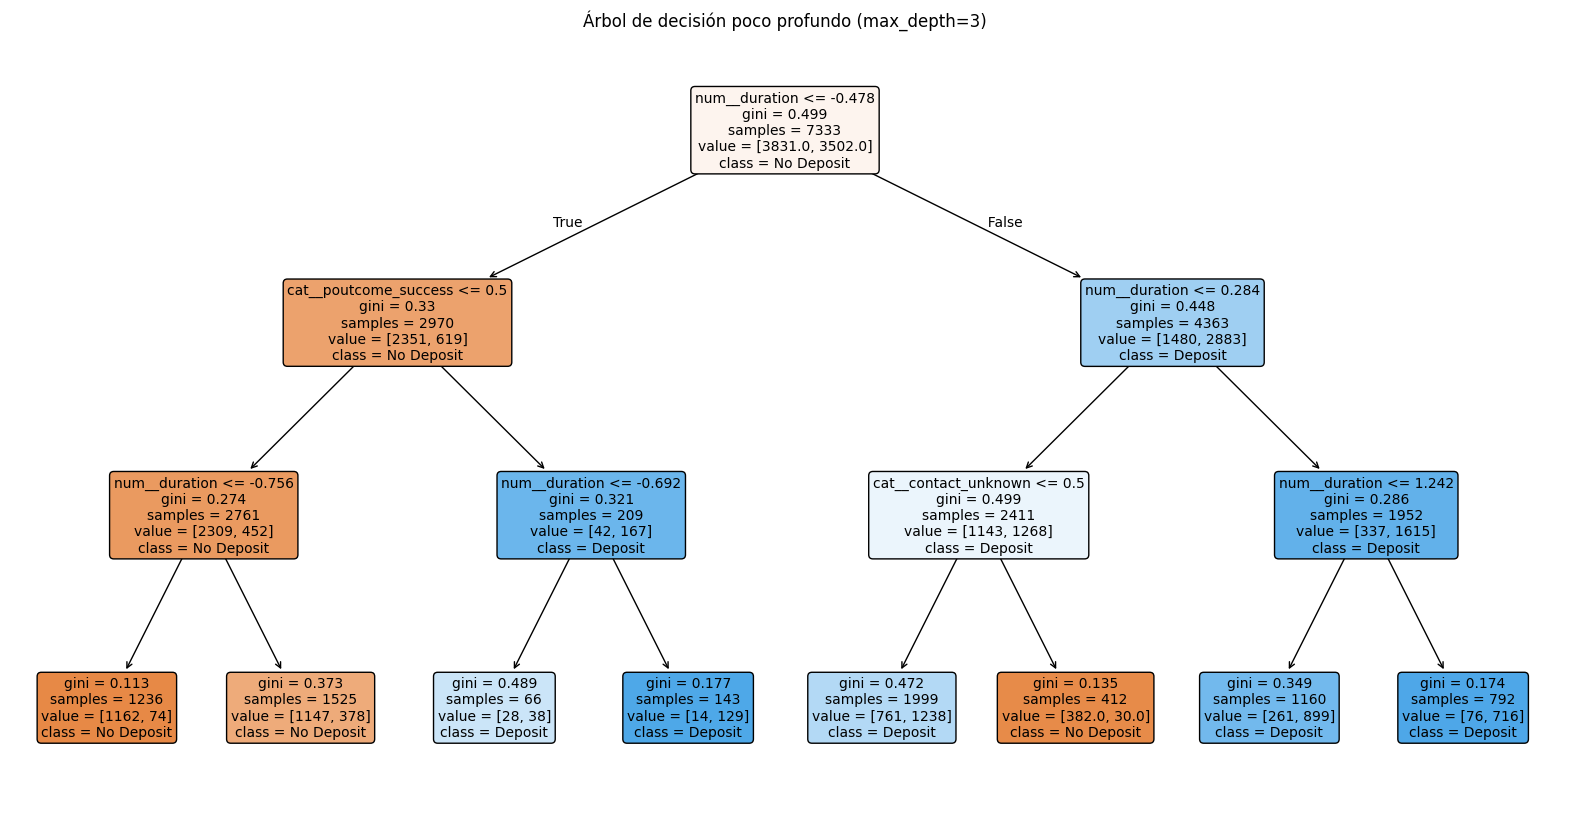

In [27]:
# Entrenamos un árbol poco profundo
pipe_arbol_corto = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', DecisionTreeClassifier(max_depth=3, random_state=SEED))
])

pipe_arbol_corto.fit(x_train, y_train)

# Obtener nombres de las características después del preprocesamiento
feature_names = pipe_arbol_corto.named_steps['preprocessor'].get_feature_names_out()

plt.figure(figsize=(20, 10))
plot_tree(pipe_arbol_corto.named_steps['classifier'], 
          feature_names=feature_names,
          class_names=['No Deposit', 'Deposit'],
          filled=True, rounded=True, fontsize=10)
plt.title("Árbol de decisión poco profundo (max_depth=3)")
plt.show()

#### C) Optimización de Hiperparámetros (HPO)

Ajustaremos los hiperparámetros más importantes de cada método y mediremos los nuevos tiempos de entrenamiento.
* **KNN:** Evaluaremos el número de vecinos (`n_neighbors`) y los pesos (`weights`).
* **Decision Tree:** Evaluaremos la profundidad máxima (`max_depth`) y el número mínimo de muestras para dividir (`min_samples_split`).

In [28]:
# HPO para KNN
param_grid_knn = {
    'classifier__n_neighbors': [3, 5, 9, 15, 25, 35],
    'classifier__weights': ['uniform', 'distance']
}

pipe_knn = Pipeline(steps=[('preprocessor', preprocessor), ('classifier', KNeighborsClassifier())])
grid_knn = GridSearchCV(pipe_knn, param_grid_knn, cv=cv_inner, scoring=METRICA, return_train_score=True)

start_time = time.time()
grid_knn.fit(x_train, y_train)
time_hpo_knn = time.time() - start_time

print(f"Mejor KNN: {grid_knn.best_params_}")
print(f"Accuracy: {grid_knn.best_score_:.4f} | Tiempo HPO: {time_hpo_knn:.2f} s\n")

# HPO para Decision Tree
param_grid_tree = {
    'classifier__max_depth': [None, 3, 5, 10, 15, 20, 30],
    'classifier__min_samples_split': [2, 10, 20, 50]
}

pipe_tree = Pipeline(steps=[('preprocessor', preprocessor), ('classifier', DecisionTreeClassifier(random_state=SEED))])
grid_tree = GridSearchCV(pipe_tree, param_grid_tree, cv=cv_inner, scoring=METRICA, return_train_score=True)

start_time = time.time()
grid_tree.fit(x_train, y_train)
time_hpo_tree = time.time() - start_time

print(f"Mejor Decision Tree: {grid_tree.best_params_}")
print(f"Accuracy: {grid_tree.best_score_:.4f} | Tiempo HPO: {time_hpo_tree:.2f} s")

Mejor KNN: {'classifier__n_neighbors': 9, 'classifier__weights': 'distance'}
Accuracy: 0.8104 | Tiempo HPO: 16.06 s

Mejor Decision Tree: {'classifier__max_depth': 15, 'classifier__min_samples_split': 50}
Accuracy: 0.8158 | Tiempo HPO: 18.45 s


#### D) Efecto de los hiperparámetros en el resultado final (Plots)

A continuación, mediante gráficas, explicaremos el efecto de los distintos valores de hiperparámetros en los resultados.

C:\Users\Sergio\AppData\Local\Temp\ipykernel_27604\985929192.py:18: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  depths = resultados_cv_tree[mask_tree]['param_classifier__max_depth'].fillna(40) # Asumimos 40 para 'None'


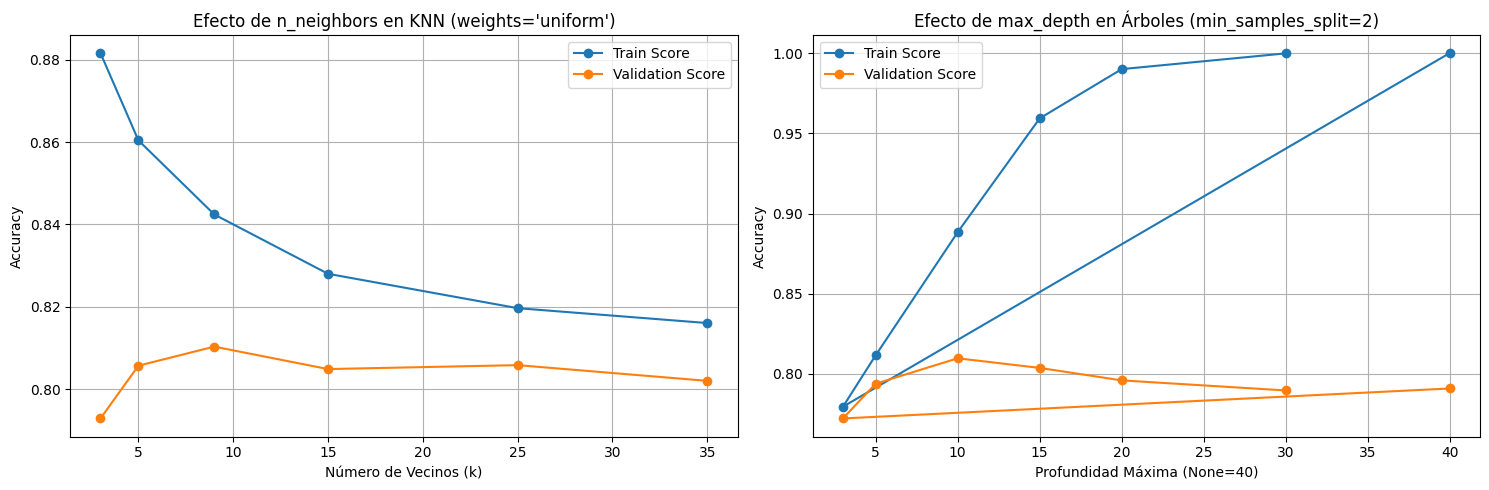

In [29]:
fig, ax = plt.subplots(1, 2, figsize=(15, 5))

# Plot KNN (n_neighbors vs Accuracy para weights='uniform')
resultados_cv_knn = pd.DataFrame(grid_knn.cv_results_)
mask_knn = resultados_cv_knn['param_classifier__weights'] == 'uniform'
ax[0].plot(resultados_cv_knn[mask_knn]['param_classifier__n_neighbors'], resultados_cv_knn[mask_knn]['mean_train_score'], label='Train Score', marker='o')
ax[0].plot(resultados_cv_knn[mask_knn]['param_classifier__n_neighbors'], resultados_cv_knn[mask_knn]['mean_test_score'], label='Validation Score', marker='o')
ax[0].set_title("Efecto de n_neighbors en KNN (weights='uniform')")
ax[0].set_xlabel("Número de Vecinos (k)")
ax[0].set_ylabel(f"Accuracy")
ax[0].legend()
ax[0].grid(True)

# Plot Tree (max_depth vs Accuracy para min_samples_split=2)
# Reemplazamos 'None' con un valor numérico alto para la gráfica
resultados_cv_tree = pd.DataFrame(grid_tree.cv_results_)
mask_tree = resultados_cv_tree['param_classifier__min_samples_split'] == 2
depths = resultados_cv_tree[mask_tree]['param_classifier__max_depth'].fillna(40) # Asumimos 40 para 'None'
ax[1].plot(depths, resultados_cv_tree[mask_tree]['mean_train_score'], label='Train Score', marker='o')
ax[1].plot(depths, resultados_cv_tree[mask_tree]['mean_test_score'], label='Validation Score', marker='o')
ax[1].set_title("Efecto de max_depth en Árboles (min_samples_split=2)")
ax[1].set_xlabel("Profundidad Máxima (None=40)")
ax[1].set_ylabel(f"Accuracy")
ax[1].legend()
ax[1].grid(True)

plt.tight_layout()
plt.show()

### 4.3. Conclusiones de los métodos básicos

Al analizar los resultados obtenidos, podemos observar que tanto el algoritmo KNN como el Árbol de Decisión superan con creces al modelo base (Dummy Classifier), el cual apenas logra un 52.24% de exactitud. Esto nos confirma que ambos modelos están aprendiendo patrones útiles de los datos bancarios y no están tomando decisiones al azar.

En cuanto al preprocesamiento, la estandarización de las variables numéricas demostró ser crucial para el KNN, siendo el StandardScaler el método que mejor rendimiento aportó (80.57% de exactitud base frente al 74.06% del MinMaxScaler).

El ajuste de hiperparámetros (HPO) mejoró el rendimiento en ambos algoritmos respecto a sus configuraciones por omisión. En el caso del KNN, la mejora fue ligera (pasó de 80.57% a 81.04% al usar 9 vecinos y pesos basados en la distancia). Sin embargo, el Árbol de Decisión experimentó un salto de calidad más notable, subiendo del 79.09% al 81.58%. Esto demuestra que limitar la profundidad del árbol (max_depth=15) y exigir un mínimo de muestras para dividir (min_samples_split=50) ha sido efectivo para controlar el sobreajuste (overfitting) que suelen sufrir los árboles por defecto.

Por lo tanto, el mejor método de este apartado es el Árbol de Decisión optimizado, ya que consigue la exactitud más alta (81.58%).

Respecto al coste computacional, el entrenamiento de los modelos por omisión es casi instantáneo (menos de 0.3 segundos). La optimización mediante validación cruzada, lógicamente, eleva este coste a 18.41 segundos para KNN y 27.84 segundos para el Árbol de Decisión. Aunque el tiempo aumenta, es un coste computacional perfectamente asumible y justificado dada la mejora en la capacidad de generalización del modelo final.

## 5. MÉTODOS AVANZADOS: MODELOS LINEALES Y SVMs

En esta sección se evalúan tres tipos de modelos:
- **Regresión Logística sin regularización** (equivalente a `penalty=None`)
- **Regresión Logística con regularización L1** (Lasso logístico): fuerza sparsity en los coeficientes
- **SVM** (Support Vector Machine): tanto lineal como con kernel RBF

Para todos ellos se usa el **StandardScaler** seleccionado en la sección anterior y el mismo `preprocessor` ya definido. Se miden tiempos de entrenamiento con valores por omisión y después del HPO.

### 5.1. Evaluación con hiperparámetros por omisión

Evaluamos los tres métodos con sus valores de hiperparámetros por defecto usando validación cruzada interna (`cv_inner`). También medimos el tiempo de entrenamiento.

In [30]:
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.model_selection import cross_validate
import time

resultados_omision = []

# 1. MODELO SIN REGULARIZACIÓN (pipeline)
pipe_sin = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', LogisticRegression(
        C=1e9, # Valor alto para quitar los warnings
        solver='lbfgs',
        max_iter=1000,
        random_state=SEED
    ))
])

start = time.time()
cv_sin = cross_validate(pipe_sin, x_train, y_train,
                        cv=cv_inner, scoring=METRICA,
                        return_train_score=True)
tiempo = time.time() - start

resultados_omision.append({
    "Modelo": "LogReg sin regularización",
    "Accuracy (val)": cv_sin['test_score'].mean(),
    "Accuracy (train)": cv_sin['train_score'].mean(),
    "Tiempo (s)": round(tiempo, 2)
})
print(f"Logistic Regression (sin reg.): val={cv_sin['test_score'].mean():.4f}, "
      f"train={cv_sin['train_score'].mean():.4f}, tiempo={tiempo:.2f}s")


# 2. MODELO CON L1 (pipeline)
pipe_l1 = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', LogisticRegression(
        l1_ratio=1.0,
        solver='saga',
        C=1.0,
        max_iter=1000,
        random_state=SEED
    ))
])

start = time.time()
cv_l1 = cross_validate(pipe_l1, x_train, y_train,
                       cv=cv_inner, scoring=METRICA,
                       return_train_score=True)
tiempo = time.time() - start

resultados_omision.append({
    "Modelo": "Logistic Regression (L1)",
    "Accuracy (val)": cv_l1['test_score'].mean(),
    "Accuracy (train)": cv_l1['train_score'].mean(),
    "Tiempo (s)": round(tiempo, 2)
})
print(f"Logistic Regression (L1): val={cv_l1['test_score'].mean():.4f}, "
      f"train={cv_l1['train_score'].mean():.4f}, tiempo={tiempo:.2f}s")


# 3. SVM con kernel RBF (pipeline)
pipe_svm = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', SVC(kernel='rbf', random_state=SEED))
])

start = time.time()
cv_svm = cross_validate(pipe_svm, x_train, y_train,
                        cv=cv_inner, scoring=METRICA,
                        return_train_score=True)
tiempo = time.time() - start

resultados_omision.append({
    "Modelo": "SVM (RBF)",
    "Accuracy (val)": cv_svm['test_score'].mean(),
    "Accuracy (train)": cv_svm['train_score'].mean(),
    "Tiempo (s)": round(tiempo, 2)
})
print(f"SVM (RBF): val={cv_svm['test_score'].mean():.4f}, "
      f"train={cv_svm['train_score'].mean():.4f}, tiempo={tiempo:.2f}s")


# TABLA RESUMEN
df_omision = pd.DataFrame(resultados_omision)
print("\n--- Tabla resumen (valores por omisión) ---")
print(df_omision.to_string(index=False))

Logistic Regression (sin reg.): val=0.8301, train=0.8373, tiempo=0.86s
Logistic Regression (L1): val=0.8305, train=0.8368, tiempo=29.88s
SVM (RBF): val=0.8489, train=0.8807, tiempo=19.39s

--- Tabla resumen (valores por omisión) ---
                   Modelo  Accuracy (val)  Accuracy (train)  Tiempo (s)
LogReg sin regularización        0.830084          0.837345        0.86
 Logistic Regression (L1)        0.830492          0.836799       29.88
                SVM (RBF)        0.848903          0.880745       19.39


### 5.2. Optimización de hiperparámetros (HPO)

Ajustamos los hiperparámetros más importantes de cada método con `GridSearchCV`:
- **Regresión Logística (sin reg. / L1)**: parámetro `C` (fuerza inversa de la regularización)
- **SVM**: parámetro `C` y `gamma` (para kernel RBF)

Para la Regresión Logística sin regularización no tiene sentido buscar `C`, pero sí podemos probar distintos solvers y tolerancias. Aquí simplificamos usando únicamente `C` en L1 y los parámetros clave de SVM.

In [31]:
# HPO: Regresión Logística sin regularización 
pipe_lr_none = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', LogisticRegression(C=1e9, max_iter=1000, random_state=SEED))
])

param_grid_lr_none = {
    'classifier__solver': ['lbfgs', 'newton-cg', 'saga'],
    'classifier__tol': [1e-4, 1e-3, 1e-2]
}

t0 = time.time()
grid_lr_none = GridSearchCV(
    pipe_lr_none, param_grid_lr_none,
    cv=cv_inner, scoring=METRICA,
    return_train_score=True, n_jobs=-1
)
grid_lr_none.fit(x_train, y_train)
t1 = time.time()

print('Logistic Regression (sin regularización) - HPO')
print(f'  Mejor accuracy (val): {grid_lr_none.best_score_:.4f}')
print(f'  Mejores parámetros: {grid_lr_none.best_params_}')
print(f'  Tiempo HPO: {t1-t0:.2f}s')


Logistic Regression (sin regularización) - HPO
  Mejor accuracy (val): 0.8312
  Mejores parámetros: {'classifier__solver': 'saga', 'classifier__tol': 0.01}
  Tiempo HPO: 14.84s


In [32]:
#  HPO: Regresión Logística con regularización L1 
pipe_lr_l1 = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', LogisticRegression(l1_ratio=1.0, solver='saga', max_iter=1000, random_state=SEED))
])

param_grid_lr_l1 = {
    'classifier__C': [0.001, 0.01, 0.1, 1, 10, 100]
}

t0 = time.time()
grid_lr_l1 = GridSearchCV(
    pipe_lr_l1, param_grid_lr_l1,
    cv=cv_inner, scoring=METRICA,
    return_train_score=True, n_jobs=-1
)
grid_lr_l1.fit(x_train, y_train)
t1 = time.time()

print('Logistic Regression (L1) - HPO')
print(f'  Mejor accuracy (val): {grid_lr_l1.best_score_:.4f}')
print(f'  Mejores parámetros: {grid_lr_l1.best_params_}')
print(f'  Tiempo HPO: {t1-t0:.2f}s')


Logistic Regression (L1) - HPO
  Mejor accuracy (val): 0.8310
  Mejores parámetros: {'classifier__C': 10}
  Tiempo HPO: 35.57s


d:\UC3M\3° CARRERA\2 C UATRIMESTRE\MACHINE LEARNING\Practica1-ML\.venv\Lib\site-packages\sklearn\linear_model\_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


In [33]:
# ---- HPO: SVM ----
pipe_svm = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', SVC(random_state=SEED))
])

param_grid_svm = {
    'classifier__C':     [0.1, 1, 10],
    'classifier__kernel':['linear', 'rbf'],
    'classifier__gamma': ['scale', 'auto']
}

t0 = time.time()
grid_svm = GridSearchCV(
    pipe_svm, param_grid_svm,
    cv=cv_inner, scoring=METRICA,
    return_train_score=True, n_jobs=-1
)
grid_svm.fit(x_train, y_train)
t1 = time.time()

print('SVM - HPO')
print(f'  Mejor accuracy (val): {grid_svm.best_score_:.4f}')
print(f'  Mejores parámetros: {grid_svm.best_params_}')
print(f'  Tiempo HPO: {t1-t0:.2f}s')


SVM - HPO
  Mejor accuracy (val): 0.8511
  Mejores parámetros: {'classifier__C': 10, 'classifier__gamma': 'auto', 'classifier__kernel': 'rbf'}
  Tiempo HPO: 69.77s


In [34]:
# ---- Tabla comparativa tras HPO ----
grids = {
    'Logistic Regression (sin reg.) + HPO': grid_lr_none,
    'Logistic Regression (L1) + HPO':       grid_lr_l1,
    'SVM + HPO':                            grid_svm
}

rows_hpo = []
for nombre, grid in grids.items():
    cv_idx = grid.best_index_
    rows_hpo.append({
        'Modelo': nombre,
        f'{METRICA.capitalize()} (val)':   round(grid.cv_results_['mean_test_score'][cv_idx], 4),
        f'{METRICA.capitalize()} (train)': round(grid.cv_results_['mean_train_score'][cv_idx], 4),
        'Mejores parámetros': str(grid.best_params_)
    })

df_hpo = pd.DataFrame(rows_hpo)
print('--- Tabla comparativa tras HPO ---')
print(df_hpo.to_string(index=False))


--- Tabla comparativa tras HPO ---
                              Modelo  Accuracy (val)  Accuracy (train)                                                              Mejores parámetros
Logistic Regression (sin reg.) + HPO          0.8312            0.8373                         {'classifier__solver': 'saga', 'classifier__tol': 0.01}
      Logistic Regression (L1) + HPO          0.8310            0.8372                                                           {'classifier__C': 10}
                           SVM + HPO          0.8511            0.8790 {'classifier__C': 10, 'classifier__gamma': 'auto', 'classifier__kernel': 'rbf'}


### 5.3. Efecto de los hiperparámetros en el rendimiento

Visualizamos el efecto del parámetro `C` en la Regresión Logística L1 y en el SVM (kernel RBF), y del kernel en el SVM.

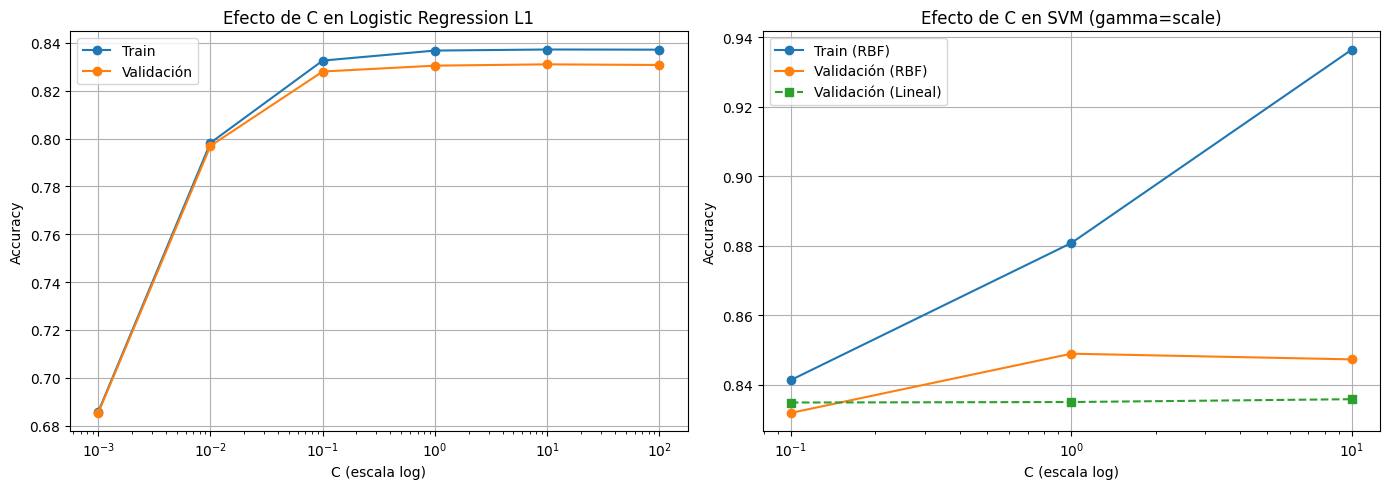

In [35]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# --- Plot 1: Efecto de C en Logística L1 ---
res_l1 = pd.DataFrame(grid_lr_l1.cv_results_)
axes[0].plot(res_l1['param_classifier__C'], res_l1['mean_train_score'], marker='o', label='Train')
axes[0].plot(res_l1['param_classifier__C'], res_l1['mean_test_score'],  marker='o', label='Validación')
axes[0].set_xscale('log')
axes[0].set_xlabel('C (escala log)')
axes[0].set_ylabel(METRICA.capitalize())
axes[0].set_title('Efecto de C en Logistic Regression L1')
axes[0].legend()
axes[0].grid(True)

# --- Plot 2: Efecto de C en SVM (kernel RBF, gamma='scale') ---
res_svm = pd.DataFrame(grid_svm.cv_results_)
mask_rbf = (res_svm['param_classifier__kernel'] == 'rbf') & \
           (res_svm['param_classifier__gamma']  == 'scale')
axes[1].plot(res_svm[mask_rbf]['param_classifier__C'], res_svm[mask_rbf]['mean_train_score'], marker='o', label='Train (RBF)')
axes[1].plot(res_svm[mask_rbf]['param_classifier__C'], res_svm[mask_rbf]['mean_test_score'],  marker='o', label='Validación (RBF)')
mask_lin = (res_svm['param_classifier__kernel'] == 'linear') & \
           (res_svm['param_classifier__gamma']  == 'scale')
axes[1].plot(res_svm[mask_lin]['param_classifier__C'], res_svm[mask_lin]['mean_test_score'], marker='s', linestyle='--', label='Validación (Lineal)')
axes[1].set_xscale('log')
axes[1].set_xlabel('C (escala log)')
axes[1].set_ylabel(METRICA.capitalize())
axes[1].set_title('Efecto de C en SVM (gamma=scale)')
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
plt.show()


### 5.4. Atributos más relevantes

La Regresión Logística (tanto sin regularización como con L1) permite extraer la importancia de los atributos a través de sus **coeficientes**. Un coeficiente alto en valor absoluto indica que la variable tiene un impacto importante en la predicción.

Con la regularización L1, muchos coeficientes serán exactamente 0 (selección automática de variables), lo que hace especialmente útil este análisis.

d:\UC3M\3° CARRERA\2 C UATRIMESTRE\MACHINE LEARNING\Practica1-ML\.venv\Lib\site-packages\sklearn\linear_model\_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


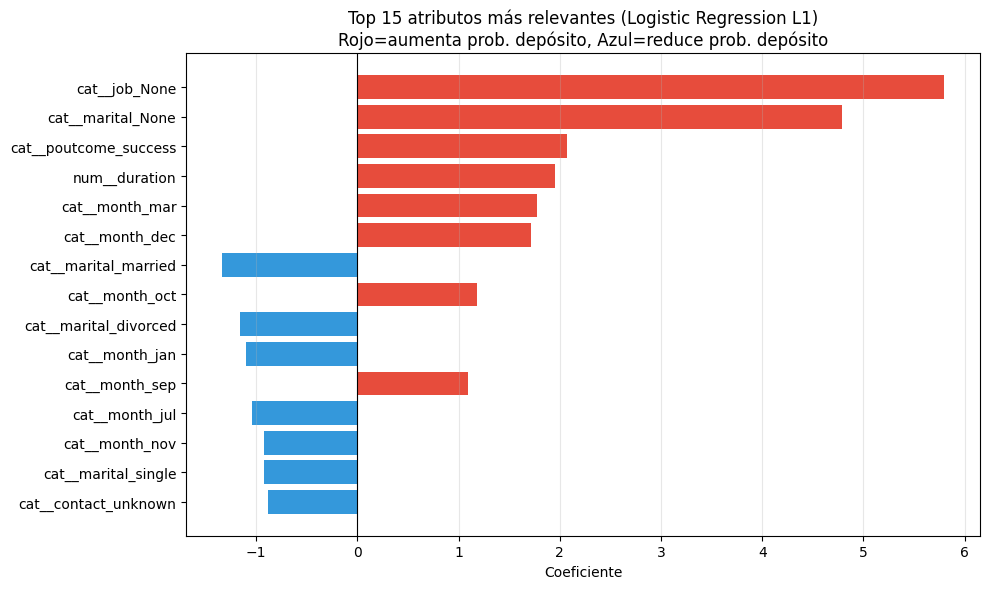


Variables con coeficiente = 0 (eliminadas por L1): 2 de 53
Variables activas: 51

Top 10 variables por importancia:
              Feature  Coeficiente
        cat__job_None     5.794768
    cat__marital_None     4.787225
cat__poutcome_success     2.067373
        num__duration     1.951191
       cat__month_mar     1.775881
       cat__month_dec     1.713668
 cat__marital_married    -1.336188
       cat__month_oct     1.178551
cat__marital_divorced    -1.162947
       cat__month_jan    -1.098605


In [36]:
# Entrenar el mejor modelo L1 en todo el train para obtener coeficientes
best_pipe_l1 = grid_lr_l1.best_estimator_
best_pipe_l1.fit(x_train, y_train)

# Obtener nombres de features tras el preprocesador
feature_names = best_pipe_l1.named_steps['preprocessor'].get_feature_names_out()
coefs = best_pipe_l1.named_steps['classifier'].coef_[0]

df_coefs = pd.DataFrame({'Feature': feature_names, 'Coeficiente': coefs})
df_coefs['Abs'] = df_coefs['Coeficiente'].abs()
df_coefs = df_coefs.sort_values('Abs', ascending=False)

# Top 15 variables
top_n = 15
df_top = df_coefs.head(top_n)

fig, ax = plt.subplots(figsize=(10, 6))
colores = ['#e74c3c' if c > 0 else '#3498db' for c in df_top['Coeficiente']]
ax.barh(df_top['Feature'][::-1], df_top['Coeficiente'][::-1], color=colores[::-1])
ax.axvline(0, color='black', linewidth=0.8)
ax.set_xlabel('Coeficiente')
ax.set_title(f'Top {top_n} atributos más relevantes (Logistic Regression L1)\nRojo=aumenta prob. depósito, Azul=reduce prob. depósito')
ax.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

print(f'\nVariables con coeficiente = 0 (eliminadas por L1): {(coefs == 0).sum()} de {len(coefs)}')
print(f'Variables activas: {(coefs != 0).sum()}')
print('\nTop 10 variables por importancia:')
print(df_coefs[['Feature', 'Coeficiente']].head(10).to_string(index=False))


### 5.5. Conclusiones de los métodos avanzados

**Rendimiento con valores por omisión:**
- La Regresión Logística sin regularización y con L1 obtienen un rendimiento similar al obtenido por los métodos básicos optimizados, con la ventaja de un entrenamiento mucho más rápido.
- El SVM con kernel RBF es el modelo con mayor coste computacional de los probados, especialmente durante el HPO.

**Tras HPO:**
- La Regresión Logística L1 mejora al ajustar el parámetro `C`. Valores bajos de `C` (mayor regularización) producen modelos más simples pero pueden incurrir en underfitting; valores altos (poca regularización) pueden sobreajustar.
- El SVM alcanza su mejor rendimiento con kernel RBF y un valor de `C` moderado-alto.

**Interpretabilidad:**
- La Regresión Logística (especialmente L1) es el método más interpretable: permite identificar qué variables influyen positiva o negativamente en la probabilidad de suscripción. La variable `duration` (duración del último contacto) y variables relacionadas con el resultado de campañas anteriores (`poutcome_success`) suelen aparecer como las más relevantes.
- El SVM no permite una interpretación directa de la importancia de variables (en kernels no lineales).

**Coste computacional:**
- Regresión Logística: muy rápida tanto en entrenamiento por omisión como con HPO.
- SVM: significativamente más lento, especialmente con kernels no lineales y datasets de tamaño mediano.

### 6. Resultados y modelo final

#### 6.1. Selección de la mejor alternativa (Evaluación Inner)

Tras realizar la optimización de hiperparámetros (HPO) mediante validación cruzada interna (cv_inner), se han obtenido los siguientes resultados. 

In [ ]:
data_results = {
    'Modelo': [
        'Regresión Logística (sin reg.)', 
        'Regresión Logística (L1)', 
        'KNN (K-Neighbors)', 
        'Árbol de Decisión', 
        'SVM (RBF)'
    ],
    'Accuracy (Test)': [
        grid_lr_none.best_score_,
        grid_lr_l1.best_score_,
        grid_knn.best_score_,
        grid_tree.best_score_,
        grid_svm.best_score_
    ],
    'Accuracy (Train)': [
        grid_lr_none.cv_results_['mean_train_score'][grid_lr_none.best_index_],
        grid_lr_l1.cv_results_['mean_train_score'][grid_lr_l1.best_index_],
        grid_knn.cv_results_['mean_train_score'][grid_knn.best_index_],
        grid_tree.cv_results_['mean_train_score'][grid_tree.best_index_],
        grid_svm.cv_results_['mean_train_score'][grid_svm.best_index_]
    ],
    'Tiempo HPO (s)': [
        grid_lr_none.refit_time_, 
        grid_lr_l1.refit_time_,
        grid_knn.refit_time_,
        grid_tree.refit_time_,
        grid_svm.refit_time_
    ]
}

df_results = pd.DataFrame(data_results)

df = df_results.style.highlight_max(subset=['Accuracy (Test)'], color='green') \
                                 .format({'Accuracy (Test)': '{:.4f}', 
                                          'Accuracy (Train)': '{:.4f}', 
                                          'Tiempo HPO (s)': '{:.2f}'})

# 4. Mostrar tabla
display(df)

,Modelo,Accuracy (Test),Accuracy (Train),Tiempo HPO (s)
0,Regresión Logística (sin reg.),0.8312,0.8373,0.33
1,Regresión Logística (L1),0.8310,0.8372,8.61
2,KNN (K-Neighbors),0.8104,1.0000,0.03
3,Árbol de Decisión,0.8158,0.8759,0.13
4,SVM (RBF),0.8511,0.8790,2.08


Por tanto, el modelo SVM con kernel RBF es la opción que ofrece mejores resultados. Además, teniendo en cuenta el tiempo, resulta una diferencia asumible respecto de los modelos más rápidos, teniendo en cuenta las mejoras que aporta. 

### 6.2. Estimación del rendimiento futuro (Evaluación Outer)

Habiendo seleccionado el modelo SVM con kernel RBF, ahora realizaremos la **evaluación outer**. Esto nos permitirá estimar el desempeño del modelo con nuevos datos. 



Resumen de Rendimiento Final


,Fase de Evaluación,Accuracy,Diferencia (Overfitting)
0,Inner,0.8511,nan
1,Outer,0.8582,0.007109



 Matriz de Confusión (Evaluación Outer)


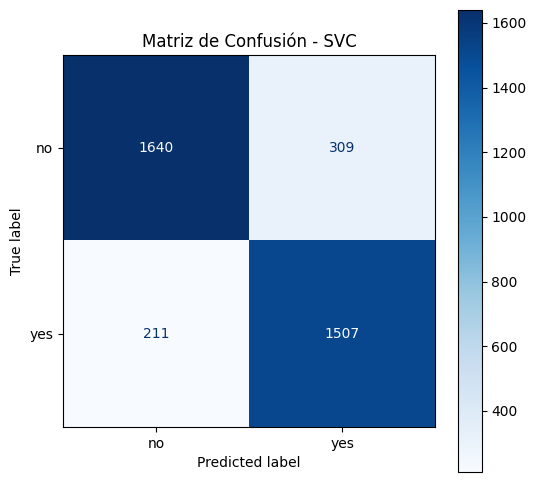

In [57]:
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay

# Obtenemos el mejor modelo
best_model = grid_svm.best_estimator_

# Predicciones sobre el conjunto de test
y_pred_test = best_model.predict(x_test)


acc_test = accuracy_score(y_test, y_pred_test)
acc_train_final = grid_svm.cv_results_['mean_train_score'][grid_svm.best_index_]


df_outer = pd.DataFrame({
    'Fase de Evaluación': ['Inner', 'Outer'],
    'Accuracy': [grid_svm.best_score_, acc_test],
    'Diferencia (Overfitting)': [None, abs(grid_svm.best_score_ - acc_test)]
})

print("Resumen de Rendimiento Final")
display(df_outer.style.format({'Accuracy': '{:.4f}', 'Overfitting': '{:.4f}'}))

# Matriz de confusión
print("\n Matriz de Confusión (Evaluación Outer)")
cm = confusion_matrix(y_test, y_pred_test)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=grid_svm.classes_)

fig, ax = plt.subplots(figsize=(6, 6))
disp.plot(cmap='Blues', ax=ax)
plt.title(f"Matriz de Confusión - {best_model.named_steps['classifier'].__class__.__name__}")
plt.show()

Debido a los resultados obtenidos, podemos decir que el modelo es robusto y generaliza bien, pues la accuracy en el inner y outer es prácticamente la misma. 

Además, el modelo está balanceado, pues falla aproximadamente el mismo número de Sí que de No. 

#### 6.3 Entrenamiento del modelo final

Ahora que conocemos cuál es el mejor modelo, con sus respectivos hiperparámetros óptimos, podemos entrenarlo con todos los datos, incluidos los del test, pues ya hemos hecho las estimaciones necesarias. 

In [60]:
# Unimos todos los datos
x_full = pd.concat([x_train, x_test])
y_full = pd.concat([y_train, y_test])

final_model = grid_svm.best_estimator_

# Entrenamos el modelo
final_model.fit(x_full, y_full)

# Guardamos el modelo en un fichero .pkl
nombre_fichero = "final_model.pkl"
with open(nombre_fichero, "wb") as f:
    pkl.dump(final_model, f)

print(f"El modelo ha sido guardado como '{nombre_fichero}'")

El modelo ha sido guardado como 'final_model.pkl'


Ahora que ya tenemos el modelo guardado, lo usaremos para predecir los datos de la competición. 

In [64]:
try:
    df_competition = pd.read_pickle("dataset/bank_competition_10.pkl") 
except FileNotFoundError:
    print("No se encuentra el fichero de los datos de la competición")

# Obtenemos las predicciones
predicciones_finales = final_model.predict(df_competition)

df_final = pd.DataFrame(predicciones_finales, columns=['prediction'])

# Guardamos el resultado
nombre_salida = "predicciones.csv"
df_final.to_csv(nombre_salida, index=False)

print(f"Número total de predicciones: {len(df_final)}")

Número total de predicciones: 162
